In [2]:
import Pkg; 
Pkg.add("DIVAnd"); 
Pkg.add("PyPlot");

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
   Installed VersionParsing ─ v1.3.0
   Installed Conda ────────── v1.10.2
   Installed JSON ─────────── v0.21.4
   Installed PyPlot ───────── v2.11.6
   Installed LaTeXStrings ─── v1.4.0
   Installed PyCall ───────── v1.96.4
   Installed Parsers ──────── v2.8.3
    Updating `~/.julia/environments/v1.11/Project.toml`
  [d330b81b] + PyPlot v2.11.6
    Updating `~/.julia/environments/v1.11/Manifest.toml`
  [8f4d0f93] + Conda v1.10.2
  [682c06a0] + JSON v0.21.4
  [b964fa9f] + LaTeXStrings v1.4.0
  [69de0a69] + Parsers v2.8.3
  [438e738f] + PyCall v1.96.4
  [d330b81b] + PyPlot v2.11.6
  [81def892] + VersionParsing v1.3.0
    Building Conda ─→ `~/.julia/scratchspaces/44cfe95a-1eb2-52ea-b672-e2afdf69b78f/b19db3927f0db4151cb86d073689f2428e524576/build.log`
    Building PyCall → `~/.julia/scratchspaces/44cfe95a-

[ Info: Directory already exists
[ Info: Directory already exists


 10.282567 seconds (76.86 k allocations: 6.571 GiB, 8.17% gc time, 0.18% compilation time)


[ Info: Created figure ./figures/In[3]


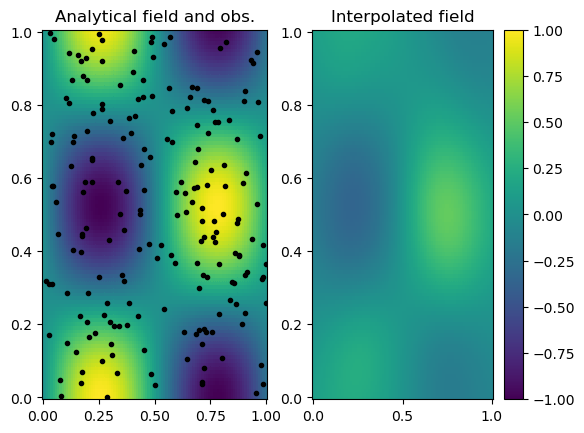

In [3]:
using DIVAnd          # Package for Data-Interpolating Variational Analysis (DIVA)
using PyPlot          # Julia interface to matplotlib for plotting

include("./prep_dirs.jl")  # Include helper file (likely defines output directories, e.g., figdir)

# ---------------------------------------------------------------
# Define a synthetic function that depends on space (x,y,z) and time (t).
# This will be our "true" underlying field that we try to reconstruct.
fun(x, y, z, t) = sin.(6x) .* cos.(6y) + sin.(6z) .* cos.(6x) .* sin.(2 * pi * t)

# ---------------------------------------------------------------
# Generate synthetic observations
nobs = 200                 # number of observations
x = rand(nobs)             # random x-coordinates in [0,1]
y = rand(nobs)             # random y-coordinates in [0,1]
z = 0.5 .+ 0.01 * rand(nobs) # z near 0.5 with small variation
t = rand(nobs)             # random time values in [0,1]
f = fun.(x, y, z, t)          # observed values sampled from the analytical function

# ---------------------------------------------------------------
# Define the size of the output interpolation grid
testsizexy = 100   # number of grid points in x and y directions
testsizez = 2     # number of grid points in z direction
testsizet = 4     # number of grid points in t direction

# ---------------------------------------------------------------
# Define the interpolation domain
# DIVAnd_rectdom creates:
#   - mask: valid domain mask (here all points valid)
#   - pm, pn, po, pq: grid metrics (inverse resolution per dimension)
#   - xi, yi, zi, ti: 4D arrays of grid coordinates
mask, (pm, pn, po, pq), (xi, yi, zi, ti) = DIVAnd_rectdom(
    range(0, stop=1, length=testsizexy),  # x grid
    range(0, stop=1, length=testsizexy),  # y grid
    range(0, stop=1, length=testsizez),   # z grid
    range(0, stop=1, length=testsizet)    # t grid
)

# ---------------------------------------------------------------
# Reference field: analytical solution on the grid
# Used for comparison with the interpolated solution
fref = fun.(xi, yi, zi, ti)

# ---------------------------------------------------------------
# Interpolation parameters
len = (0.1, 0.1, 0.1, 0.1)   # correlation lengths (in each dimension)
epsilon2 = 1.0            # observation error variance (normalized)

# ---------------------------------------------------------------
# Run the interpolation (DIVA)
#   fi = interpolated field on the grid
#   s  = analysis error (not used here)
#   moddim=[0,0,0,1] specifies periodicity:
#     - non-periodic in x,y,z
#     - periodic in time (t), because it cycles
@time fi, s = DIVAndrun(
    mask, (pm, pn, po, pq), (xi, yi, zi, ti),
    (x, y, z, t), f,
    len, epsilon2;
    moddim=[0, 0, 0, 1]
)

# ---------------------------------------------------------------
# Plotting results
# Plot a 2D slice at z=1 and t=3 (arbitrary slice for visualization)

subplot(1, 2, 1)  # left panel
pcolor(xi[:, :, 1, 3], yi[:, :, 1, 3], fref[:, :, 1, 3], vmin=-1., vmax=1.)
clim(-1, 1)                  # fix color limits
plot(x, y, "k.")              # overlay observation points
title("Analytical field and obs.")

subplot(1, 2, 2)  # right panel
pcolor(xi[:, :, 1, 3], yi[:, :, 1, 3], fi[:, :, 1, 3], vmin=-1., vmax=1.)
colorbar()                   # add colorbar
clim(-1, 1)
title("Interpolated field")

# ---------------------------------------------------------------
# Save figure to file
figname = joinpath(figdir, basename(replace(@__FILE__, r".jl$" => ".png")))
savefig(figname)
@info "Created figure " * figname

# ---------------------------------------------------------------
# License info
# This script is under the GNU General Public License v2 or later
